### Homework 5

In [1]:
# Load packages 
#%pip install us
import us
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

In [2]:
# Load Data from HCRIS
data_2009 = pd.read_csv('../Homework4/data/output/data-2009.csv')
data_2010 = pd.read_csv('../Homework4/data/output/data-2010.csv')
data_2011 = pd.read_csv('../Homework4/data/output/data-2011.csv')
data_2012 = pd.read_csv('../Homework4/data/output/data-2012.csv')
data_2013 = pd.read_csv('../Homework4/data/output/data-2013.csv')
data_2014 = pd.read_csv('../Homework4/data/output/data-2014.csv')
data_2015 = pd.read_csv('../Homework4/data/output/data-2015.csv')
data_2016 = pd.read_csv('../Homework4/data/output/data-2016.csv')
data_2017 = pd.read_csv('../Homework4/data/output/data-2017.csv')
data_2018 = pd.read_csv('../Homework4/data/output/data-2018.csv')

In [3]:
data_2010["tot_uncomp_care_charges"] = data_2010["uncomp_care"]

In [4]:
data = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018], ignore_index=True)

In [5]:
data_kff = pd.read_excel('KFF_data.xlsx')

In [6]:
data_kff.head()

,raw_data,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Title: Status of State Action on the Medicaid ...,NaN,NaN,NaN,NaN,NaN
1,Timeframe: September 2025,NaN,NaN,NaN,NaN,NaN
2,Location,Status of Medicaid Expansion Decision,Expansion Implementation Date,Expansion Adopted Through Ballot Initiative,Trigger Law In Place,Footnotes
3,United States,Adopted: 41 states (incl. DC) Not Adopted: 10...,NaN,Yes: 7 states No: 34 states (incl. DC) Not ...,Yes: 13 states No: 28 states (incl. DC) Not ...,NaN
4,Alabama,Not Adopted,NaN,NaN,NaN,NaN


In [7]:
data_kff = pd.read_excel('raw_data.xlsx')

In [8]:
data_kff

,Location,Adopted: 41 states (incl. DC) Not Adopted: 10 states,Expansion Implementation Date
0,Alabama,Not Adopted,NaN
1,Alaska,Adopted,9/1/2015
2,Arizona,Adopted,1/1/2014
3,Arkansas,Adopted,1/1/2014
4,California,Adopted,1/1/2014
5,Colorado,Adopted,1/1/2014
6,Connecticut,Adopted,1/1/2014
7,Delaware,Adopted,1/1/2014
8,District of Columbia,Adopted,1/1/2014
9,Florida,Not Adopted,NaN


In [9]:
kff_final = data_kff.copy()
kff_final["expanded"] = kff_final["Adopted: 41 states (incl. DC)  Not Adopted: 10 states"] == "Adopted"

In [10]:
kff_final["year"] = pd.to_datetime(kff_final["Expansion Implementation Date"], errors="coerce").dt.year.astype("Int64")
kff_final = kff_final.rename(columns={"Location": "state"})
kff_final = kff_final.rename(columns={"year": "expansion_year"})

In [11]:
kff_final.head()

,state,Adopted: 41 states (incl. DC) Not Adopted: 10 states,Expansion Implementation Date,expanded,expansion_year
0,Alabama,Not Adopted,NaN,False,<NA>
1,Alaska,Adopted,9/1/2015,True,2015
2,Arizona,Adopted,1/1/2014,True,2014
3,Arkansas,Adopted,1/1/2014,True,2014
4,California,Adopted,1/1/2014,True,2014


In [12]:
data["state"] = data["state"].apply(
    lambda x: us.states.lookup(x).name if us.states.lookup(x) else x
)
data.loc[data["state"] == "DC", "state"] = "District of Columbia"
data = data[~data["state"].isin(["Puerto Rico", "Virgin Islands", "Guam", "Northern Mariana Islands"])]

In [13]:
merged = data.merge(kff_final, on="state", how="left")
merged.head()

,provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,...,tot_uncomp_care_charges,tot_uncomp_care_partial_pmts,bad_debt,depr_HIT,year,source,Adopted: 41 states (incl. DC) Not Adopted: 10 states,Expansion Implementation Date,expanded,expansion_year
0,10001,2009-10-01,2010-09-30,2011-08-09,2011-08-05,v1996,408.0,1.116894e+09,250212573.0,866681575.0,...,90806676.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
1,10005,2009-10-01,2010-09-30,2011-03-09,2011-03-07,v1996,114.0,2.110556e+08,67006321.0,144049273.0,...,25141783.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
2,10006,2009-07-01,2010-06-30,2010-12-14,2010-12-13,v1996,358.0,6.320590e+08,129883282.0,502175755.0,...,97595621.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
3,10007,2009-10-01,2010-09-30,2011-02-28,2011-02-28,v1996,78.0,4.452468e+07,14349804.0,30174875.0,...,3959905.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
4,10008,2010-01-01,2010-12-31,2011-06-15,2011-06-14,v1996,29.0,2.750480e+07,13044287.0,14460509.0,...,3037069.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>


# Question 1

In [14]:
merged.columns

Index(['provider_number', 'fy_start', 'fy_end', 'date_processed',
       'date_created', 'data_source', 'beds', 'tot_charges', 'net_pat_rev',
       'tot_discounts', 'tot_operating_exp', 'ip_charges', 'icu_charges',
       'ancillary_charges', 'tot_discharges', 'mcare_discharges',
       'mcaid_discharges', 'tot_mcare_payment', 'secondary_mcare_payment',
       'street', 'city', 'state', 'zip', 'county', 'name', 'uncomp_care',
       'cost_to_charge', 'new_cap_ass', 'cash', 'fixed_assets', 'depr_land',
       'depr_bldg', 'depr_lease', 'depr_fixed_equip', 'depr_auto',
       'depr_major_equip', 'depr_minor_equip', 'current_assets',
       'current_liabilities', 'pps_ip_charges', 'pps_op_charges',
       'pps_mcare_cost', 'pps_pgm_cost', 'hvbp_payment', 'hrrp_payment',
       'tot_uncomp_care_charges', 'tot_uncomp_care_partial_pmts', 'bad_debt',
       'depr_HIT', 'year', 'source',
       'Adopted: 41 states (incl. DC)  Not Adopted: 10 states',
       'Expansion Implementation Date', 'e

In [15]:
question_1 = (
    merged.groupby("year", as_index=False)["tot_uncomp_care_charges"]
      .mean()
      .assign(avg_charged_millions=lambda x: x["tot_uncomp_care_charges"] / 1_000_000)
      [["year", "avg_charged_millions"]]
)

In [16]:
question_1 = question_1.round({"avg_charged_millions": 2}).rename(
    columns={
        "year": "Year",
        "avg_charged_millions": "Mean Uncompensated Care in Millions ($)"
    }
)
question_1

,Year,Mean Uncompensated Care in Millions ($)
0,2010,30.26
1,2011,17.40
2,2012,18.77
3,2013,19.98
4,2014,17.96
5,2015,15.51
6,2016,17.87
7,2017,22.56
8,2018,24.95


The amount of uncompensated care has changed from year to year with some increases and some decreases. Overall, from 2010 to 2018, the average uncompensated care in millions has decreased from $30.26 million to $24.95 million.

## Question 2

In [17]:
question_2 = merged[(merged["expansion_year"] == 2014) | (merged["expansion_year"].isna())].copy()

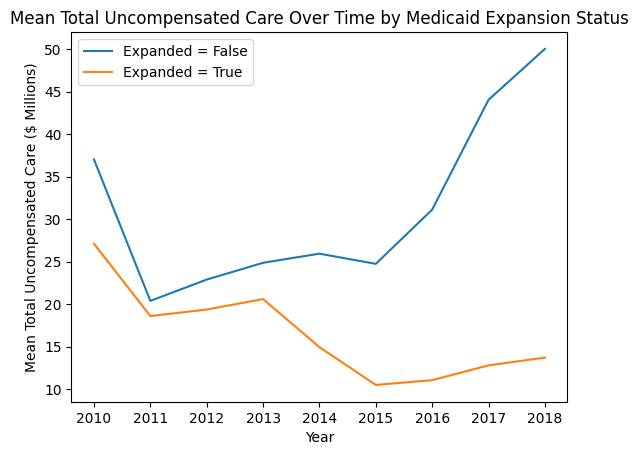

In [18]:
plot_2 = (
    question_2.groupby(["year", "expanded"], as_index=False)["tot_uncomp_care_charges"]
      .mean()
)

plot_2["total_uncompensated_millions"] = plot_2["tot_uncomp_care_charges"] / 1_000_000

for status, group in plot_2.groupby("expanded"):
    plt.plot(group["year"], group["total_uncompensated_millions"], label=f"Expanded = {status}")

plt.xlabel("Year")
plt.ylabel("Mean Total Uncompensated Care ($ Millions)")
plt.title("Mean Total Uncompensated Care Over Time by Medicaid Expansion Status")
plt.legend()
plt.show()

The data suggests a possible treatment effect. It appears that uncompensated care increased in states that did not expand Medicaid and decreased in states that did expand.

## Question 3

In [19]:
plot_2.head()

,year,expanded,tot_uncomp_care_charges,total_uncompensated_millions
0,2010,False,3.701839e+07,37.018391
1,2010,True,2.710861e+07,27.108612
2,2011,False,2.039265e+07,20.392650
3,2011,True,1.860909e+07,18.609085
4,2012,False,2.290052e+07,22.900521


In [20]:
question_3 = question_2[(question_2["year"] == 2012) | (question_2["year"] == 2015)].copy()
question_3["post"] = question_3["year"] >= 2015

In [21]:
dd_means = (
    question_3
    .groupby(["expanded", "post"], as_index=False)
    .agg(mean_uncomp_care=("tot_uncomp_care_charges", lambda x: x.mean() / 1_000_000))
)

dd_means["expanded"] = dd_means["expanded"].map({True: "Expanded", False: "Not Expanded"})
dd_means["post"] = dd_means["post"].map({True: "2015 (Post)", False: "2012 (Pre)"})

In [22]:
# table_3 = dd_means.round({"mean_uncomp_care": 2}).rename(
#     columns={
#         "expanded": "Medicaid Expansion",
#         "post": "Time Period",
#         "mean_uncomp_care": "Avg Uncompensated Care in Millions ($)"
#     }
# )
# table_3

In [23]:
table_3 = (
    dd_means
    .pivot(index="expanded", columns="post", values="mean_uncomp_care")
    .reindex(index=["Expanded", "Not Expanded"], columns=["2012 (Pre)", "2015 (Post)"])
    .round(2)
)

table_3.index.name = ""
table_3.columns.name = ""

table_3

,2012 (Pre),2015 (Post)
,,
Expanded,19.38,10.51
Not Expanded,22.90,24.75


## Question 4 

The average uncompensated care increased in the states that did not expand Medicaid and decreased in the States that did expand, on average. This makes sense as the population that received insurance as a result of the ACA Medicaid expansion would have been contributing to the uncompensated care. Now, they have insurance that pays the hospital, decreasing the uncompensated care. However, the States that did not expand had the same population still receiving uncompensated care three years later.

## Question 5

In [24]:
dd_dat_for_reg = question_3.copy()

dd_dat_for_reg["expanded"] = dd_dat_for_reg["expanded"].astype(int)
dd_dat_for_reg["post"] = dd_dat_for_reg["post"].astype(int)

dd_dat_for_reg["uncomp_care_m"] = dd_dat_for_reg["tot_uncomp_care_charges"] / 1_000_000

dd_est = smf.ols("uncomp_care_m ~ expanded + post + expanded:post", data=dd_dat_for_reg).fit()
dd_est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          uncomp_care_m   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     17.47
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.73e-11
Time:                        14:55:05   Log-Likelihood:                -35729.
No. Observations:                6448   AIC:                         7.147e+04
Df Residuals:                    6444   BIC:                         7.149e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        22.9005      1.747     13.110      0.000      19.476      26.325
expanded         -3.5221      2.227     -1.581      0.114      -7.888       0.844
post              1.8460      2.478      0.745      0.456      -3.011       6.703
expanded:post   -10.7119      3.159     -3.391      0.001     -16.905      -4.519
==============================================================================
Omnibus:                    11978.680   Durbin-Watson:                   1.720
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         22481498.783
Skew:                          13.877   Prob(JB):                         0.00
Kurtosis:                     290.937   Cond. No.                         7.79
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
results_table = pd.DataFrame({
    "Coefficient": dd_est.params,
    "Std. Error": dd_est.bse,
    "t-stat": dd_est.tvalues,
    "p-value": dd_est.pvalues
}).round(3)

results_table.index = ["Intercept", "Expansion", "Post", "Expansion × Post"]

results_table

,Coefficient,Std. Error,t-stat,p-value
Intercept,22.901,1.747,13.110,0.000
Expansion,-3.522,2.227,-1.581,0.114
Post,1.846,2.478,0.745,0.456
Expansion × Post,-10.712,3.159,-3.391,0.001


## Question 6

In [26]:
# Dropped NA values for uncomp_care; should this actually be 0?
question_6 = dd_dat_for_reg.dropna(
    subset=["uncomp_care_m", "expanded", "post", "provider_number", "year", "state"]
).copy()
m_dd = smf.ols("uncomp_care_m ~ post + expanded + expanded:post", data=question_6).fit()
m_twfe = smf.ols(
    "uncomp_care_m ~ expanded:post + C(provider_number) + C(year)",
    data=question_6
).fit(cov_type="cluster", cov_kwds={"groups": question_6["state"]})

m_twfe.summary()

/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3442, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          uncomp_care_m   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                -1.279e+14
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               1.00
Time:                        14:55:34   Log-Likelihood:                -26779.
No. Observations:                6448   AIC:                         6.044e+04
Df Residuals:                    3005   BIC:                         8.376e+04
Df Model:                        3442                                         
Covariance Type:              cluster                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       22.4143      1.446     15.501      0.000      19.580      25.248
C(provider_number)[T.10005]    -15.4711   8.56e-11  -1.81e+11      0.000     -15.471     -15.471
C(provider_number)[T.10006]    -14.8811    8.8e-11  -1.69e+11      0.000     -14.881     -14.881
C(provider_number)[T.10007]    -23.1063   8.81e-11  -2.62e+11      0.000     -23.106     -23.106
C(provider_number)[T.10008]    -22.4111      1.446    -15.499      0.000     -25.245     -19.577
C(provider_number)[T.10009]    -21.8450      1.446    -15.107      0.000     -24.679     -19.011
C(provider_number)[T.10011]      4.1024   8.63e-11   4.75e+10      0.000       4.102       4.102
C(provider_number)[T.10012]    -16.8682   8.67e-11  -1.95e+11      0.000     -16.868     -16.868
C(provider_number)[T.10016]      5.3461      1.446      3.697      0.000       2.512       8.180
C(provider_number)[T.10018]    -21.5681      1.446    -14.916      0.000     -24.402     -18.734
C(provider_number)[T.10019]    -16.4478   8.67e-11   -1.9e+11      0.000     -16.448     -16.448
C(provider_number)[T.10021]    -22.4717   8.66e-11   -2.6e+11      0.000     -22.472     -22.472
C(provider_number)[T.10022]    -22.3639   8.65e-11  -2.58e+11      0.000     -22.364     -22.364
C(provider_number)[T.10023]     10.3518   8.65e-11    1.2e+11      0.000      10.352      10.352
C(provider_number)[T.10024]      9.9921   8.62e-11   1.16e+11      0.000       9.992       9.992
C(provider_number)[T.10025]    -22.0265      1.446    -15.233      0.000     -24.861     -19.192
C(provider_number)[T.10029]      3.1128   8.64e-11    3.6e+10      0.000       3.113       3.113
C(provider_number)[T.10032]    -23.1120   8.62e-11  -2.68e+11      0.000     -23.112     -23.112
C(provider_number)[T.10033]    159.1374   8.67e-11   1.84e+12      0.000     159.137     159.137
C(provider_number)[T.10034]    -22.4272   8.72e-11  -2.57e+11      0.000     -22.427     -22.427
C(provider_number)[T.10035]    -15.2423   8.65e-11  -1.76e+11      0.000     -15.242     -15.242
C(provider_number)[T.10036]    -24.2273      1.446    -16.755      0.000     -27.061     -21.393
C(provider_number)[T.10038]    -13.8012   8.64e-11   -1.6e+11      0.000     -13.801     -13.801
C(provider_number)[T.10039]     55.3827   8.55e-11   6.48e+11      0.000      55.383      55.383
C(provider_number)[T.10040]     11.8002   8.58e-11   1.38e+11      0.000      11.800      11.800
C(provider_number)[T.10043]    -20.7137      1.446    -14.325      0.000     -23.548     -17.880
C(provider_number)[T.10044]    -21.6779   8.62e-11  -2.51e+11      0.000     -21.678     -21.678
C(provider_number)[T.10045]    -20.6062   8.59e-11   -2.4e+11      0.000     -20.606     -20.606
C(provider_number)[T.10046]      6.6678      1.446      4.611      0.000    

In [27]:
table_6 = pd.DataFrame({
    "Coefficient": [m_twfe.params["expanded:post"]],
    "Std. Error": [m_twfe.bse["expanded:post"]],
    "t-stat": [m_twfe.tvalues["expanded:post"]],
    "p-value": [m_twfe.pvalues["expanded:post"]]
}, index=["Expansion × Post"]).round(3)

table_6

,Coefficient,Std. Error,t-stat,p-value
Expansion × Post,-11.348,4.587,-2.474,0.013


The difference in differences treatment effect becomes more negative when adding in hospital and year fixed effects. This means that Medicaid expansion is associated with even greater reductions in uncompensated care when controlling for differences in hospitals and shocks for common years. 

## Question 7

In [28]:
question_7 = merged[(merged["year"] == 2012) | (merged["year"] == 2015)].copy()
question_7["post"] = question_7["year"] >= 2015

In [29]:
dd_dat_for_reg_7 = question_7.copy()

# dd_dat_for_reg_7["expanded"] = dd_dat_for_reg_7["expanded"].astype(int)
dd_dat_for_reg_7["post"] = dd_dat_for_reg_7["post"].astype(int)

dd_dat_for_reg_7["treated_by_2015"] = (
    dd_dat_for_reg_7["expansion_year"].notna() &
    (dd_dat_for_reg_7["expansion_year"] <= 2015)
).astype(int)

dd_dat_for_reg_7["uncomp_care_m"] = dd_dat_for_reg_7["tot_uncomp_care_charges"] / 1_000_000

In [30]:
# Dropped NA values for uncomp_care; should this actually be 0?
question_7_2 = dd_dat_for_reg_7.dropna(
    subset=["uncomp_care_m", "treated_by_2015", "post", "provider_number", "year", "state"]
).copy()
m_twfe_7 = smf.ols(
    "uncomp_care_m ~ treated_by_2015:post + C(provider_number) + C(year)",
    data=question_7_2
).fit(cov_type="cluster", cov_kwds={"groups": question_7_2["state"]})

m_twfe_7.summary()

/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4587, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          uncomp_care_m   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                -1.124e+14
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               1.00
Time:                        14:56:42   Log-Likelihood:                -35101.
No. Observations:                8582   AIC:                         7.938e+04
Df Residuals:                    3994   BIC:                         1.118e+05
Df Model:                        4587                                         
Covariance Type:              cluster                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       22.2448      0.919     24.216      0.000      20.444      24.045
C(provider_number)[T.10005]    -15.4711   5.93e-10  -2.61e+10      0.000     -15.471     -15.471
C(provider_number)[T.10006]    -14.8811   6.01e-10  -2.48e+10      0.000     -14.881     -14.881
C(provider_number)[T.10007]    -23.1063   5.97e-10  -3.87e+10      0.000     -23.106     -23.106
C(provider_number)[T.10008]    -22.2416      0.919    -24.212      0.000     -24.042     -20.441
C(provider_number)[T.10009]    -21.6754      0.919    -23.596      0.000     -23.476     -19.875
C(provider_number)[T.10011]      4.1024   5.87e-10   6.99e+09      0.000       4.102       4.102
C(provider_number)[T.10012]    -16.8682   5.87e-10  -2.87e+10      0.000     -16.868     -16.868
C(provider_number)[T.10016]      5.5156      0.919      6.004      0.000       3.715       7.316
C(provider_number)[T.10018]    -21.7377      0.919    -23.664      0.000     -23.538     -19.937
C(provider_number)[T.10019]    -16.4478   5.87e-10   -2.8e+10      0.000     -16.448     -16.448
C(provider_number)[T.10021]    -22.4717   5.87e-10  -3.83e+10      0.000     -22.472     -22.472
C(provider_number)[T.10022]    -22.3639   5.87e-10  -3.81e+10      0.000     -22.364     -22.364
C(provider_number)[T.10023]     10.3518   5.87e-10   1.76e+10      0.000      10.352      10.352
C(provider_number)[T.10024]      9.9921   5.87e-10    1.7e+10      0.000       9.992       9.992
C(provider_number)[T.10025]    -21.8570      0.919    -23.794      0.000     -23.657     -20.057
C(provider_number)[T.10029]      3.1128   5.87e-10    5.3e+09      0.000       3.113       3.113
C(provider_number)[T.10032]    -23.1120   5.87e-10  -3.93e+10      0.000     -23.112     -23.112
C(provider_number)[T.10033]    159.1374   5.87e-10   2.71e+11      0.000     159.137     159.137
C(provider_number)[T.10034]    -22.4272   5.87e-10  -3.82e+10      0.000     -22.427     -22.427
C(provider_number)[T.10035]    -15.2423   5.87e-10   -2.6e+10      0.000     -15.242     -15.242
C(provider_number)[T.10036]    -24.3968      0.919    -26.559      0.000     -26.197     -22.596
C(provider_number)[T.10038]    -13.8012   5.87e-10  -2.35e+10      0.000     -13.801     -13.801
C(provider_number)[T.10039]     55.3827   5.87e-10   9.44e+10      0.000      55.383      55.383
C(provider_number)[T.10040]     11.8002   5.87e-10   2.01e+10      0.000      11.800      11.800
C(provider_number)[T.10043]    -20.5442      0.919    -22.365      0.000     -22.345     -18.744
C(provider_number)[T.10044]    -21.6779   5.87e-10  -3.69e+10      0.000     -21.678     -21.678
C(provider_number)[T.10045]    -20.6062   5.87e-10  -3.51e+10      0.000     -20.606     -20.606
C(provider_number)[T.10046]      6.8373      0.919      7.443      0.000    

In [31]:
table_7 = pd.DataFrame({
    "Coefficient": [m_twfe_7.params["treated_by_2015:post"]],
    "Std. Error": [m_twfe_7.bse["treated_by_2015:post"]],
    "t-stat": [m_twfe_7.tvalues["treated_by_2015:post"]],
    "p-value": [m_twfe_7.pvalues["treated_by_2015:post"]]
}, index=["Expansion × Post"]).round(3)

table_7

,Coefficient,Std. Error,t-stat,p-value
Expansion × Post,-10.54,3.818,-2.76,0.006


The difference in difference treatment effect decreased (became less negative). This is likely due to states that expanded in 2015, as these would still be considered as treated but they would not see the cost savings yet (in terms of uncompensated care). 

## Question 8

In [32]:
question_2.head()

,provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,...,tot_uncomp_care_charges,tot_uncomp_care_partial_pmts,bad_debt,depr_HIT,year,source,Adopted: 41 states (incl. DC) Not Adopted: 10 states,Expansion Implementation Date,expanded,expansion_year
0,10001,2009-10-01,2010-09-30,2011-08-09,2011-08-05,v1996,408.0,1.116894e+09,250212573.0,866681575.0,...,90806676.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
1,10005,2009-10-01,2010-09-30,2011-03-09,2011-03-07,v1996,114.0,2.110556e+08,67006321.0,144049273.0,...,25141783.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
2,10006,2009-07-01,2010-06-30,2010-12-14,2010-12-13,v1996,358.0,6.320590e+08,129883282.0,502175755.0,...,97595621.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
3,10007,2009-10-01,2010-09-30,2011-02-28,2011-02-28,v1996,78.0,4.452468e+07,14349804.0,30174875.0,...,3959905.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
4,10008,2010-01-01,2010-12-31,2011-06-15,2011-06-14,v1996,29.0,2.750480e+07,13044287.0,14460509.0,...,3037069.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>


In [33]:
question_8 = question_2.copy()
question_8["uncomp_care_m"] = question_8["tot_uncomp_care_charges"] / 1_000_000

question_8["time_to_treat"] = np.where(
    question_8["expanded"].astype(bool),
    question_8["year"] - question_8["expansion_year"],
    0
)

question_8["time_to_treat"] = question_8["time_to_treat"].clip(lower=-3)

mod_event = smf.ols(
    "uncomp_care_m ~ C(year, Treatment(reference=2013)):expanded + C(provider_number) + C(year)",
    data=question_8
).fit()

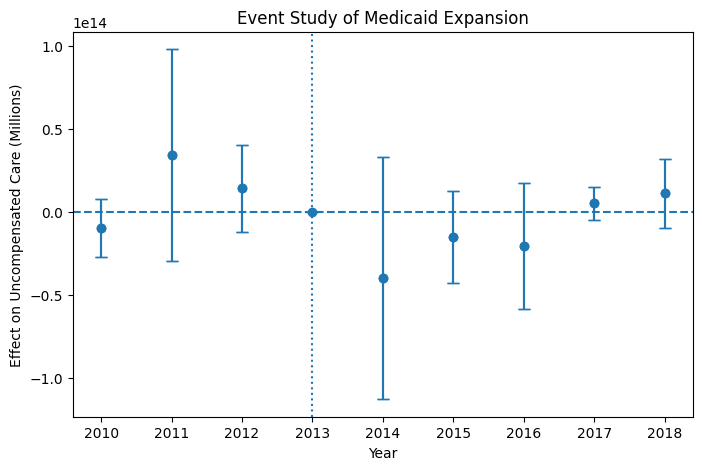

In [34]:
# Pull coefficients and confidence intervals
params = mod_event.params
conf = mod_event.conf_int()

# Keep only the event-study interaction terms
event_terms = [term for term in params.index if ":expanded" in term]

# Build plotting dataframe
plot_df = pd.DataFrame({
    "term": event_terms,
    "coef": [params[t] for t in event_terms],
    "ci_low": [conf.loc[t, 0] for t in event_terms],
    "ci_high": [conf.loc[t, 1] for t in event_terms]
})

# Extract year from the term names
plot_df["year"] = plot_df["term"].str.extract(r"T\.(\d+)").astype(int)

# Add 2013 manually as the omitted reference year
ref_row = pd.DataFrame({
    "term": ["Reference"],
    "coef": [0],
    "ci_low": [0],
    "ci_high": [0],
    "year": [2013]
})

plot_df = pd.concat([plot_df, ref_row], ignore_index=True).sort_values("year")

# Plot
plt.figure(figsize=(8, 5))
plt.errorbar(
    plot_df["year"],
    plot_df["coef"],
    yerr=[plot_df["coef"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["coef"]],
    fmt="o",
    capsize=4
)
plt.axhline(0, linestyle="--")
plt.axvline(2013, linestyle=":")
plt.xlabel("Year")
plt.ylabel("Effect on Uncompensated Care (Millions)")
plt.title("Event Study of Medicaid Expansion")
plt.show()

In [35]:
question_8 = question_2.copy()
question_8["uncomp_care_m"] = question_8["tot_uncomp_care_charges"] / 1_000_000

question_8 = question_8.dropna(
    subset=["uncomp_care_m", "expanded", "provider_number", "year", "state"]
).copy()

question_8["time_to_treat"] = np.where(
    question_8["expanded"].astype(bool),
    question_8["year"] - question_8["expansion_year"],
    0
)

question_8["time_to_treat"] = question_8["time_to_treat"].clip(lower=-3)

mod_event = smf.ols(
    "uncomp_care_m ~ C(year, Treatment(reference=2013)):expanded + C(provider_number) + C(year)",
    data=question_8
).fit(cov_type="cluster", cov_kwds={"groups": question_8["state"]})

/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


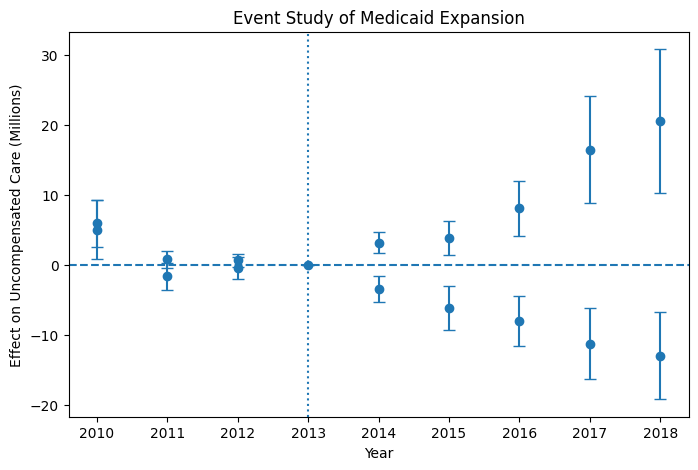

In [36]:
# Pull coefficients and confidence intervals
params = mod_event.params
conf = mod_event.conf_int()

# Keep only the event-study interaction terms
event_terms = [term for term in params.index if ":expanded" in term]

# Build plotting dataframe
plot_df = pd.DataFrame({
    "term": event_terms,
    "coef": [params[t] for t in event_terms],
    "ci_low": [conf.loc[t, 0] for t in event_terms],
    "ci_high": [conf.loc[t, 1] for t in event_terms]
})

# Extract year from the term names
plot_df["year"] = plot_df["term"].str.extract(r"T\.(\d+)").astype(int)

# Add 2013 manually as the omitted reference year
ref_row = pd.DataFrame({
    "term": ["Reference"],
    "coef": [0],
    "ci_low": [0],
    "ci_high": [0],
    "year": [2013]
})

plot_df = pd.concat([plot_df, ref_row], ignore_index=True).sort_values("year")

# Plot
plt.figure(figsize=(8, 5))
plt.errorbar(
    plot_df["year"],
    plot_df["coef"],
    yerr=[plot_df["coef"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["coef"]],
    fmt="o",
    capsize=4
)
plt.axhline(0, linestyle="--")
plt.axvline(2013, linestyle=":")
plt.xlabel("Year")
plt.ylabel("Effect on Uncompensated Care (Millions)")
plt.title("Event Study of Medicaid Expansion")
plt.show()

## Question 9

In [41]:
question_9 = merged.copy()
question_9["uncomp_care_m"] = question_9["tot_uncomp_care_charges"] / 1_000_000
question_9 = question_9.dropna(
    subset=["uncomp_care_m", "expanded", "provider_number", "year", "state"]
).copy()

question_9["time_to_treat"] = np.where(
    question_9["expanded"].astype(bool),
    question_9["year"] - question_9["expansion_year"],
    0
)

question_9["time_to_treat"] = question_9["time_to_treat"].clip(lower=-3, upper=3)

mod_event_9 = smf.ols(
    "uncomp_care_m ~ C(time_to_treat)*expanded + C(provider_number) + C(year)",
    data=question_9
).fit(cov_type="cluster", cov_kwds={"groups": question_9["state"]})

/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


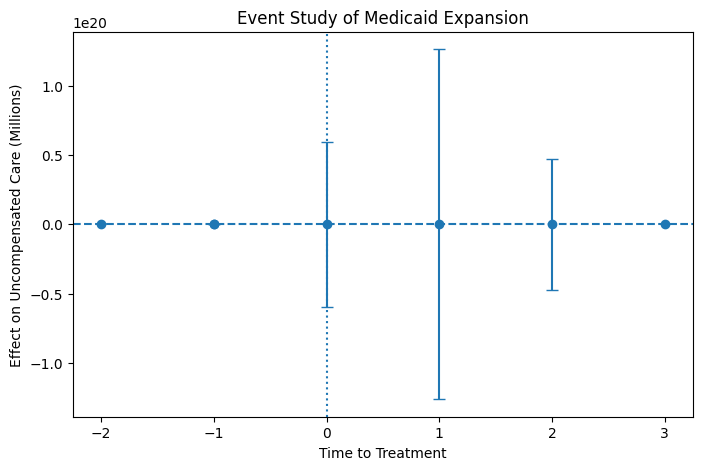

In [42]:
# Pull coefficients and confidence intervals
plot_df["time_to_treat"] = plot_df["term"].str.extract(r"T\.(-?\d+\.?\d*)").astype(float)
params = mod_event_9.params
conf = mod_event_9.conf_int()

event_terms = [term for term in params.index if "time_to_treat" in term and ":expanded" in term]

plot_df = pd.DataFrame({
    "term": event_terms,
    "coef": [params[t] for t in event_terms],
    "ci_low": [conf.loc[t, 0] for t in event_terms],
    "ci_high": [conf.loc[t, 1] for t in event_terms]
})

plot_df["time_to_treat"] = (
    plot_df["term"]
    .str.extract(r"T\.(-?\d+\.?\d*)")[0]
    .astype(float)
)

# add omitted reference period manually if needed
ref_row = pd.DataFrame({
    "term": ["Reference"],
    "coef": [0],
    "ci_low": [0],
    "ci_high": [0],
    "time_to_treat": [-1]
})

plot_df = pd.concat([plot_df, ref_row], ignore_index=True).sort_values("time_to_treat")

plt.figure(figsize=(8, 5))
plt.errorbar(
    plot_df["time_to_treat"],
    plot_df["coef"],
    yerr=[
        plot_df["coef"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["coef"]
    ],
    fmt="o",
    capsize=4
)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.xlabel("Time to Treatment")
plt.ylabel("Effect on Uncompensated Care (Millions)")
plt.title("Event Study of Medicaid Expansion")
plt.show()

## Question 10

Questions 5-9 all support the trend that expanded Medicaid decreases uncompensated care overtime when compared to states that did not expand Medicaid. Question 9 demonstrates that there the parallel trend assumption is valid. The pre-period uncompensated care effects are very close to 0, indicating the uncompensated care does not decrease before expanding Medicaid. One issue with staggered Medicaid expansion is that the states that expanded later on are still considered expanded. As demonstrated in question 7, this makes the effects differences in uncompensated care smaller because the states are considered treated even before they undergo the treatment.

Questions for class:
-For question 5 do we need to use the fixest pacakge or can we use his python code? 
-For question 6 I dropped NA values for uncomp_care; should this actually be 0?